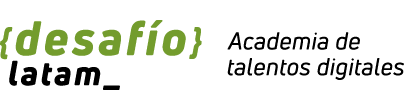

# <center><font color='green'>Regresión logística</font></center>

Veremos ahora cómo implementar un modelo de regresión logística para una base de datos, buscando relacionar algunas características de pacientes con su diagnóstico.

Para esto, cargaremos las bibliotecas necesarias y la data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix\
    , precision_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc


df=pd.read_csv('breast cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
df.shape

(569, 33)

In [3]:
df['diagnosis'].value_counts('%')

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

Preparamos los datos. Para ello podríamos hacer un análisis exploratorio de los mismos, en n uestro caso solo eliminaremos una columna con valores nulos.

In [4]:
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

In [5]:
variables=df.columns
print(variables)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## <font color='green'>Nuestro modelo de regresión</font>

Vamos a escoger algunas variables de nuestra base de datos y aplicaremos el modelo de regresión logística.

In [8]:
X = df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']]
y = df['diagnosis']

# Mapear las etiquetas 'M' (maligno) a 1 y 'B' (benigno) a 0
y = y.map({'M': 1, 'B': 0})

# Crea una instancia del modelo de regresión logística
model = LogisticRegression()

# Ajusta el modelo a los datos
model.fit(X, y)

# Realiza predicciones con el modelo
y_pred = model.predict(X)

# Calcula la precisión del modelo
accuracy = accuracy_score(y, y_pred)
print(f'Acuracy del modelo: {accuracy}')

# Calcula y muestra la matriz de confusión
confusion = confusion_matrix(y, y_pred)
print('Matriz de Confusión:')
print(confusion)

# Genera un informe de clasificación que incluye precisión, recuperación y F1-score
report = classification_report(y, y_pred)
print('Informe de Clasificación:')
print(report)

Acuracy del modelo: 0.9121265377855887
Matriz de Confusión:
[[337  20]
 [ 30 182]]
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       357
           1       0.90      0.86      0.88       212

    accuracy                           0.91       569
   macro avg       0.91      0.90      0.91       569
weighted avg       0.91      0.91      0.91       569



In [9]:
type(report)

str

In [10]:
y_pred[:10]

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1])

## <font color='green'>Evaluando el modelo</font>

Calcularemos ahora las métricas de evaluación para nuestro modelo.

In [11]:
model.predict_proba(X)[:10]

array([[0.00935554, 0.99064446],
       [0.02590582, 0.97409418],
       [0.00303237, 0.99696763],
       [0.68393115, 0.31606885],
       [0.0047338 , 0.9952662 ],
       [0.88327434, 0.11672566],
       [0.02524146, 0.97475854],
       [0.49611223, 0.50388777],
       [0.30080454, 0.69919546],
       [0.31133285, 0.68866715]])

In [12]:
sum(model.predict_proba(X)[:1][0])

1.0

AUC-ROC: 0.9724380318165002
AUC-PR: 0.9613590912834901


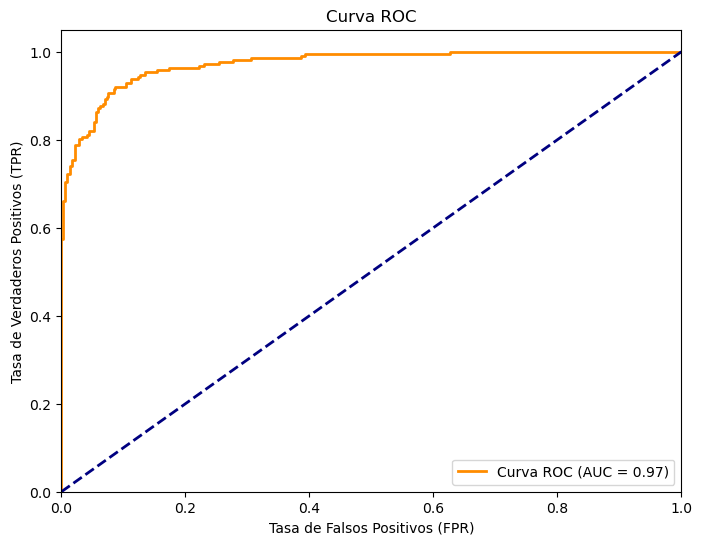

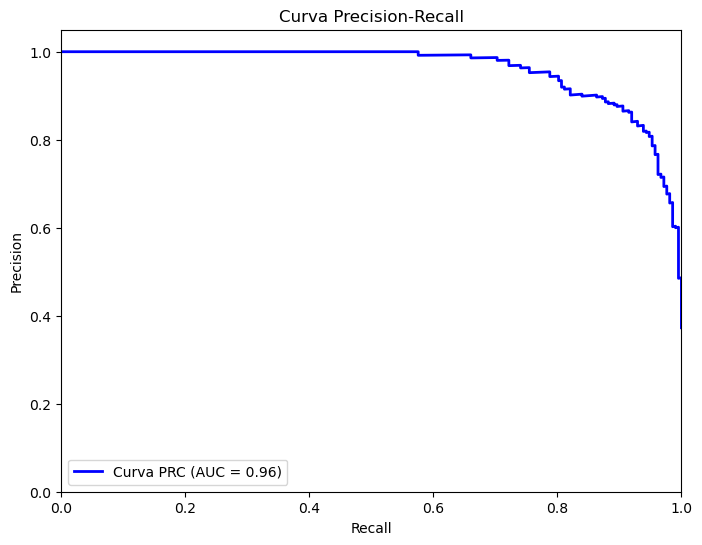

In [13]:
# Obtener las probabilidades de predicción
y_prob = model.predict_proba(X)[:, 1]

# Calcular el AUC-ROC
roc_auc = roc_auc_score(y, y_prob)
print(f'AUC-ROC: {roc_auc}')

# Calcular el AUC-PR
prc_auc = average_precision_score(y, y_prob)
print(f'AUC-PR: {prc_auc}')

# Calcular la curva ROC
fpr, tpr, thresholds_roc = roc_curve(y, y_prob)

# Calcular la curva PRC
precision, recall, thresholds_prc = precision_recall_curve(y, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')

# Graficar la curva PRC
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Curva PRC (AUC = %0.2f)' % prc_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='lower left')

# Mostrar las curvas ROC y PRC
plt.show()

## <font color='green'> Desbalanceo de clases

Veremos a continuación un ejemplo de clases desbalanceadas y el efecto que esto provoca en el modelo de regresión logistica.

In [14]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,LabelEncoder

# Cargamos los datos
df=pd.read_csv('creditcard.csv')
# Eliminamos Duplicados
df.drop_duplicates(inplace=True)





In [15]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [16]:
df['Class'].value_counts('%')

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [17]:
# Eliminamos Nulos, y los datos "Time" y "Amount" por no estar correctamente codificadas
df=df.dropna()
df=df.drop(['Time','Amount'] , axis = 1)
col=df.columns.to_list()

# Es necesario escalar
sc=StandardScaler()

# Identifiquemos las variables X e y
X=df.drop('Class', axis = 1)
Y=df['Class']
X=sc.fit_transform(X)
print(df['Class'].value_counts(''))

Class
0    283253
1       473
Name: count, dtype: int64


In [18]:
X[0]

array([-0.70108232, -0.04168726,  1.68010106,  0.97662253, -0.24702025,
        0.34801219,  0.19369982,  0.08443421,  0.33353384,  0.08568786,
       -0.54166226, -0.62039108, -0.99654956, -0.32705029,  1.60361453,
       -0.53973372,  0.24664646,  0.02898986,  0.49701081,  0.32627339,
       -0.02477688,  0.38348342, -0.17744405,  0.11015694,  0.24705862,
       -0.39262206,  0.33303251, -0.06584955])

Es evidente que la clase 0 tiene muchos más casos que la clase 1. Veamos qué ocurre si ignoramos este hecho y si utilizamos SMOTE para corregir este hecho.

In [20]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE

X = df.drop(columns=["Class"]).values

# Variable dependiente
y = df["Class"].values

# Estandarizar las características
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Modelo de Regresión Logística sin SMOTE
logistic_regression_model = LogisticRegression(random_state=42)
logistic_regression_model.fit(X, y)

# Realizar predicciones en el conjunto de datos sin SMOTE
y_pred = logistic_regression_model.predict(X)

# Calcular AUC-ROC sin SMOTE
roc_auc = roc_auc_score(y, y_pred)

# Calcular AUC-PR sin SMOTE
average_precision = average_precision_score(y, y_pred)

# Ahora, aplicaremos SMOTE y crearemos el modelo nuevamente
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Modelo de Regresión Logística con SMOTE
logistic_regression_model_smote = LogisticRegression(random_state=42)
logistic_regression_model_smote.fit(X_resampled, y_resampled)

# Realizar predicciones en el conjunto de datos con SMOTE
y_pred_smote = logistic_regression_model_smote.predict(X)

# Calcular AUC-ROC con SMOTE
roc_auc_smote = roc_auc_score(y, y_pred_smote)

# Calcular AUC-PR con SMOTE
average_precision_smote = average_precision_score(y, y_pred_smote)

# Imprimir AUC-ROC y AUC-PR para ambos modelos
print("AUC-ROC sin SMOTE:", roc_auc)
print("AUC-PR sin SMOTE:", average_precision)
print("AUC-ROC con SMOTE:", roc_auc_smote)
print("AUC-PR con SMOTE:", average_precision_smote)

AUC-ROC sin SMOTE: 0.8001355126165643
AUC-PR sin SMOTE: 0.522134284159605
AUC-ROC con SMOTE: 0.9435529621510123
AUC-PR con SMOTE: 0.05036137098367884


Un aumento en el AUC-ROC con SMOTE es común, ya que SMOTE mejora la separación entre las clases, pero una disminución en el AUC-PR puede ocurrir debido a la introducción de ejemplos sintéticos que pueden no ser ideales para la clasificación precisa de la clase minoritaria. La elección de qué métrica es más importante depende del contexto de tu problema. Si la precisión en la detección de la clase minoritaria es crucial, entonces debes prestar más atención al AUC-PR y considerar ajustes adicionales en el modelo o en la técnica de muestreo.

<center><strong>¡Ahora podemos regresar a nuestra presentación</strong></center>

In [21]:
y.sum()

473

In [22]:
y_resampled.sum()  # 1s en la data nueva

283253

In [23]:
y_resampled.size # total datos nuevos

566506

In [24]:
y_resampled.size - y_resampled.sum() # 0s en la data nueva

283253

In [25]:
report1 = classification_report(y, y_pred)
print('Informe de Clasificación:')
print(report1)

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    283253
           1       0.87      0.60      0.71       473

    accuracy                           1.00    283726
   macro avg       0.93      0.80      0.85    283726
weighted avg       1.00      1.00      1.00    283726



In [26]:
# Genera un informe de clasificación que incluye precisión, recuperación y F1-score
report2 = classification_report(y, y_pred_smote)
print('Informe de Clasificación:')
print(report2)

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    283253
           1       0.05      0.91      0.10       473

    accuracy                           0.97    283726
   macro avg       0.53      0.94      0.55    283726
weighted avg       1.00      0.97      0.99    283726



# Prueba

In [27]:
import pandas as pd

df_p = pd.read_csv('cardio.csv')

In [28]:
df_p.head()

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [29]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   object 
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(5), object(2)
memory usage: 529.9+ KB


In [30]:
df_p.describe()

,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4133.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,49.584946,1.978950,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,8.572160,1.019791,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [31]:
df_p.shape

(4238, 16)

In [32]:
df_p.loc[:,'cigsPerDay':].corr()

,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
cigsPerDay,1.000000,-0.046134,-0.032707,-0.066146,-0.037067,-0.026320,-0.088780,-0.056632,-0.092856,0.075157,-0.058960,0.057884
BPMeds,-0.046134,1.000000,0.117365,0.261187,0.052047,0.080558,0.254219,0.194227,0.100668,0.015233,0.051176,0.087489
prevalentStroke,-0.032707,0.117365,1.000000,0.074830,0.006949,0.000067,0.057009,0.045190,0.025891,-0.017676,0.018431,0.061810
prevalentHyp,-0.066146,0.261187,0.074830,1.000000,0.077808,0.163993,0.696755,0.615751,0.301318,0.147261,0.086834,0.177603
diabetes,-0.037067,0.052047,0.006949,0.077808,1.000000,0.040278,0.111283,0.050329,0.087036,0.048994,0.617627,0.097317
totChol,-0.026320,0.080558,0.000067,0.163993,0.040278,1.000000,0.208908,0.165182,0.115767,0.091125,0.046408,0.082184
sysBP,-0.088780,0.254219,0.057009,0.696755,0.111283,0.208908,1.000000,0.784002,0.326981,0.182246,0.140621,0.216429
diaBP,-0.056632,0.194227,0.045190,0.615751,0.050329,0.165182,0.784002,1.000000,0.377588,0.181255,0.061231,0.145299
BMI,-0.092856,0.100668,0.025891,0.301318,0.087036,0.115767,0.326981,0.377588,1.000000,0.067678,0.087377,0.075192
heartRate,0.075157,0.015233,-0.017676,0.147261,0.048994,0.091125,0.182246,0.181255,0.067678,1.000000,0.094500,0.022913


In [33]:
df_p['TenYearCHD'].value_counts('%')

TenYearCHD
0    0.848042
1    0.151958
Name: proportion, dtype: float64

In [34]:
df_p['TenYearCHD'].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [35]:
from imblearn.over_sampling import SMOTE

In [36]:
df_p.describe()

,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4133.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,49.584946,1.978950,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,8.572160,1.019791,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000
